In [1]:
import os
HOME = os.path.expanduser("~") + '/gdrive/DataHII/'

In [2]:
import os
import sys
import glob
import numpy as np
import  scipy.optimize as op
import matplotlib.pyplot as plt
import urllib.request
from astropy.io import fits as fits
from astropy.table import Table
import pandas as pd
import urllib.request
import requests
import astropy.units as u
import astropy
from astropy.coordinates import SkyCoord
from pathlib import Path
from numpy import savetxt
from PyAstronomy import pyasl
from scipy.interpolate import interp1d
from dustmaps.sfd import SFDQuery
import astropy.cosmology.units as cu
from astropy.coordinates import match_coordinates_sky
import io
from astroquery.sdss import SDSS
from astropy import coordinates as coords
import matplotlib.image as mpimg
from astroquery.ipac.ned import Ned as ned
import seaborn as sns
import warnings
from mw_plot import mw_radec # milkyway plane in RA/DEC
from matplotlib import gridspec
from matplotlib.patches import FancyArrowPatch
from collections import namedtuple, OrderedDict
import gc
import matplotlib
matplotlib.use("Agg")
plt.ioff()

/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/dustmaps/config.py:74: ConfigWarning: Configuration file not found:

    /home/holman/.dustmapsrc

To create a new configuration file in the default location, run the following python code:

    from dustmaps.config import config
    config.reset()

Note that this will delete your configuration! For example, if you have specified a data directory, then dustmaps will forget about its location.
  warn(('Configuration file not found:\n\n'


## SDSS galaxies

/home/hollman/gdrive/DataHII/gal_info_dr7_v5_2.fit.gz already exist


(array([2.63440e+04, 1.88535e+05, 1.42359e+05, 1.52329e+05, 1.39796e+05,
        1.14497e+05, 8.54860e+04, 6.70230e+04, 1.04170e+04, 3.30000e+01]),
 array([-16.67872238,  -6.58381319,   3.51109624,  13.60600567,
         23.70091438,  33.79582214,  43.89073181,  53.98564148,
         64.08055115,  74.17546082,  84.27037048]),
 <BarContainer object of 10 artists>)

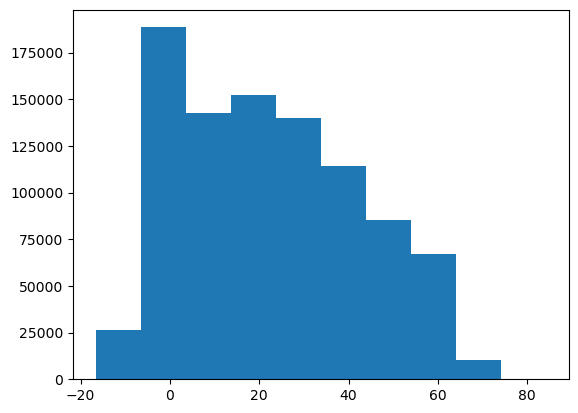

In [3]:
DATA_URL="http://das.sdss.org/spectro/ss_tar_26/"
file="gal_info_dr7_v5_2.fit.gz"
local_file = os.path.join(HOME,file)

if not os.path.exists(local_file):
        print("downloading DR7 quasar dataset from %s to %s"
              % (DATA_URL+file, local_file ))
        tmp = urllib.request.urlretrieve(DATA_URL+local_file, local_file)
        print ("Downloaded file"+local_file)
else:
    print("%s already exist"%(local_file))

catalog=Table.read(local_file)
w=((catalog['RA']!=catalog['DEC']) & (catalog['RA']>0) & ((catalog['DEC']>=-90) | (catalog['DEC']<=90)) & (catalog['Z']>=0) & ( catalog['Z'] != float('nan') ) & ( catalog['DEC'] != float('nan') ) & ( catalog['RA'] != float('nan') ))
reduced_cat=catalog[w]
#reduced_cat
#reduced_cat = catalog
plt.hist(reduced_cat['DEC'])
#sns.histplot(data=reduced_cat['DEC'], x='value')

In [4]:
NED = pd.read_csv(HOME + '/SPS/NED_Chavez2012.csv', sep=",", header=0)
NED.columns
NED

,No.,ObjectName,RA,Dec,Redshift(z)
0,1,UM 199,1.737614,0.857181,0.073682
1,2,UM 282,12.947112,0.161124,0.037556
2,3,UM 336,23.436174,0.953078,0.019236
3,4,MRK 0627,131.643397,36.438978,0.010634
4,5,SBS 0934+546,144.556301,54.473618,0.102102
...,...,...,...,...,...
123,124,WISEA J101136.07+263027.5,152.900317,26.507660,0.054666
124,125,WISEA J162152.58+151855.9,245.469098,15.315537,0.034341
125,126,WISEA J090506.84+223834.7,136.278600,22.642759,0.125548
126,127,WISEA J094000.50+203122.7,145.002109,20.522973,0.044799


In [5]:
def SDSS_namerecover(name):
    name = str(name)
    name = name.replace('.fit','')
    name = name.replace('spSpec-','')
    name = name.replace('-',',')
    return name

Dbox_ls = os.listdir(HOME + '/Dropbox_DATA/DR7spectra/')
Dbox_ls

SDSS_string = "MJD,PLATEID,FIBERID\n"

for i in Dbox_ls:
    A = SDSS_namerecover(i)
    SDSS_string = SDSS_string + A +"\n"
    #print(A)
    del A

SDSS_df_Dbox = pd.read_csv(io.StringIO(SDSS_string), sep=',')


SDSS_df_Dbox

,MJD,PLATEID,FIBERID
0,51608,267,421
1,51690,341,606
2,51793,388,457
3,51810,415,141
4,51811,381,370
...,...,...,...
116,53815,2427,117
117,53815,2430,117
118,53852,2483,254
119,53857,2489,123


In [6]:
FOLDER = ['1d_23','1d_25','1d_26']
PLATE = '0266'
URL = "https://data.sdss.org/sas/dr7/das2/spectro/"


def check_link(path): # Function that takes care of seeing if the file exists on the web or not
    r = requests.head(path)
    status = r.status_code == requests.codes.ok
    if (status == True):
        return True
    else:
        return False





In [11]:
download_list = []

with open(HOME + '/SPS/Final_speclist.csv', 'w') as file:

    file.write("N,Name,RA,DEC,Z,PLATE,MJD,FIBERID\n")

    warnings.filterwarnings('ignore') 
    c = 0
    for n in range(len(NED)): #len(NED)

        plate_key, mjd_key, fiber_key = '','',''

        filtro = False

        U = NED['ObjectName'][n]
        print(f'[{n}] Search for {U} \n')
        #Searching by coordinates

        pst = coords.SkyCoord(ra = NED['RA'][n] * u.degree,
                        dec = NED['Dec'][n] * u.degree,
                        frame='icrs')
        xid = SDSS.query_region(pst, radius='3.0 arcmin', spectro=True)

        empty_class = str(type(xid))

        F_try = 0

        #Searching by plate,mjd and fiber

        if (empty_class != "<class 'NoneType'>"):

            #print(f'Matches in 3.0 arcmin separation: {len(xid)}\n')

            for i in xid:
                mjd_eval, plate_eval, fiber_eval = i['mjd'],i['plate'],i['fiberID']
                w = np.array((SDSS_df_Dbox['MJD'] == mjd_eval) & (SDSS_df_Dbox['PLATEID'] == plate_eval) & (SDSS_df_Dbox['FIBERID'] == fiber_eval))

                if (True in w):
                    #print('Match in ...')
                    spec_id = SDSS.query_specobj(plate = plate_eval, mjd = mjd_eval, fiberID = fiber_eval)
                    #print(spec_id)
                    plate_key, mjd_key, fiber_key = plate_eval,mjd_eval,fiber_eval
                    #print('\n')
                    F_try += 1
            if (F_try == 1):
                print('Unique match \n')
                filtro = True
                #print('\n \n')
            else:
                #print('Problem searching by unique match, proceedind to search by coordinates...')
                ra1 = np.array(reduced_cat['RA'])
                dec1 = np.array(reduced_cat['DEC'])
                D1 = np.array(reduced_cat['Z'])
                ra2 = np.array(NED['RA'][n])
                dec2 = np.array(NED['Dec'][n])
                D2 = np.array(NED['Redshift(z)'][n])
                SDSS_cat = SkyCoord(ra=ra1*u.degree, 
                            dec=dec1*u.degree,
                            distance = D1 * u.kpc)
                NED_cat = SkyCoord(ra=ra2*u.degree,
                                    dec=dec2*u.degree,
                                    distance = D2 * u.kpc)
                idx, d2d, d3d = NED_cat.match_to_catalog_sky(SDSS_cat)
                sdss_vals = [reduced_cat['MJD'][idx],reduced_cat['PLATEID'][idx],reduced_cat['FIBERID'][idx]]
                #print('Minimum separation: ',d2d * u.arcmin)

                max_sep = 1.0 * u.arcmin
                sep_constraint = d2d > max_sep

                if sep_constraint:
                    print('Too far away from object -> Rejected \n')
                else:
                    #print(f'MJD:{sdss_vals[0]} ,PLATEID:{sdss_vals[1]}, FIBERID:{sdss_vals[2]} ','\n')
                    spec_id = SDSS.query_specobj(plate = sdss_vals[1], mjd = sdss_vals[0], fiberID = sdss_vals[2])
                    #print(spec_id)
                    #print('\n \n')
                    plate_key, mjd_key, fiber_key = sdss_vals[1],sdss_vals[0],sdss_vals[2]
                    filtro = True
        else:
            #print(n, f'{U} NOT found in SDSS base')
            #print(f'Proceed to Search for coordinates match ')

            ra1 = np.array(reduced_cat['RA'])
            dec1 = np.array(reduced_cat['DEC'])
            D1 = np.array(reduced_cat['Z'])
            ra2 = np.array(NED['RA'][n])
            dec2 = np.array(NED['Dec'][n])
            D2 = np.array(NED['Redshift(z)'][n])
            SDSS_cat = SkyCoord(ra=ra1*u.degree, 
                        dec=dec1*u.degree,
                        distance = D1 * u.kpc)
            NED_cat = SkyCoord(ra=ra2*u.degree,
                                dec=dec2*u.degree,
                                distance = D2 * u.kpc)
            idx, d2d, d3d = NED_cat.match_to_catalog_sky(SDSS_cat)
            sdss_vals = [reduced_cat['MJD'][idx],reduced_cat['PLATEID'][idx],reduced_cat['FIBERID'][idx]]
            #print('Minimum separation: ',d2d * u.arcmin)

            max_sep = 1.0 * u.arcmin
            sep_constraint = d2d > max_sep

            if sep_constraint:
                print('Too far away from object -> Rejected \n')
            else:
                #print(f'MJD:{sdss_vals[0]} ,PLATEID:{sdss_vals[1]}, FIBERID:{sdss_vals[2]} ','\n')
                spec_id = SDSS.query_specobj(plate = sdss_vals[1], mjd = sdss_vals[0], fiberID = sdss_vals[2])
                #print(spec_id)
                #print('\n \n')
                plate_key, mjd_key, fiber_key = sdss_vals[1],sdss_vals[0],sdss_vals[2]
                filtro = True

        plate_key = str(plate_key)
        mjd_key = str(mjd_key)
        fiber_key = str(fiber_key)



        if (filtro == True) and (mjd_key != '51662'):
            Name_ned,RA_ned,DEC_ned,z_ned = NED['ObjectName'][n],NED['RA'][n],NED['Dec'][n],NED['Redshift(z)'][n]
            file.write(f"{c},{Name_ned},{RA_ned},{DEC_ned},{z_ned},{plate_key},{mjd_key},{fiber_key}\n")
            c+=1




        print(plate_key, mjd_key, fiber_key)

        

        if (len(plate_key)<4) or (len(mjd_key)<5) or (len(fiber_key)<3):
            if (len(plate_key)<4):
                for x in range(4-len(plate_key)):
                    plate_key = '0' + plate_key
            if (len(mjd_key)<5):
                for y in range(5-len(mjd_key)):
                    mjd_key = '0' + mjd_key
            if (len(fiber_key)<3):
                for z in range(3-len(fiber_key)):
                    fiber_key = '0' + fiber_key

        pre_link = URL + FOLDER[0] + '/' + plate_key +"/1d/spSpec" + '-' + mjd_key + '-' + plate_key+ '-' + fiber_key + '.fit'
        if check_link(pre_link)==False:
            pre_link = URL + FOLDER[1] + '/' + plate_key +"/1d/spSpec" + '-' + mjd_key + '-' + plate_key+ '-' + fiber_key + '.fit'
            if check_link(pre_link)==False:
                pre_link = URL + FOLDER[2] + '/' + plate_key +"/1d/spSpec" + '-' + mjd_key + '-' + plate_key+ '-' + fiber_key + '.fit'
                if check_link(pre_link)==False:
                    download_list.append('Not Found')
                else:
                    download_list.append(pre_link)
            else:
                download_list.append(pre_link)
        else:
            download_list.append(pre_link)
        
        #print(pre_link,'\n')

[0] Search for UM 199 

Unique match 

388 51793 457
[1] Search for UM 282 

Unique match 

394 51913 472
[2] Search for UM 336 

Unique match 

400 51820 441
[3] Search for MRK 0627 

Unique match 

934 52672 369
[4] Search for SBS 0934+546 

Unique match 

556 51991 224
[5] Search for UM 455 

284 51662 277
[6] Search for UM 570 

Unique match 

341 51690 606
[7] Search for ESO 383-IG 043 

Too far away from object -> Rejected 

  
[8] Search for UM 162 

Unique match 

384 51821 281
[9] Search for WISEA J084220.93+115001.2 

Unique match 

2426 53795 15
[10] Search for KUG 0952+418 

Unique match 

1216 52709 619
[11] Search for TON 0542 

Unique match 

1981 53463 438
[12] Search for SHOC 391 

Unique match 

337 51997 97
[13] Search for WAS 69 

Unique match 

2112 53534 557
[14] Search for WAS 17 

Unique match 

2489 53857 123
[15] Search for WISEA J095000.75+300340.9 

Unique match 

1947 53431 448
[16] Search for WISEA J095227.57+322810.3 

Unique match 

1946 53432 609
[17] S

In [87]:
download_list = [item for item in download_list if item != 'Not Found']
fits_folder = '/HIIGs/FITS_download/'

if (os.path.exists(HOME + fits_folder) == True):
    print('Folder for spec set saving already created \n')
else:
    print(f'Folder for spec set saving created at ({HOME+fits_folder}) \n')
    os.mkdir(HOME+fits_folder)

for f in range(len(download_list)):
    print(f"({f+1}/{len(download_list)}) Downloading {download_list[f][-25:]} ...")
    direc = HOME + fits_folder + download_list[f][-25:]
    DOWNLOAD = urllib.request.urlretrieve(download_list[f], direc)

Folder for spec set saving already created 

(1/122) Downloading spSpec-51793-0388-457.fit ...
(2/122) Downloading spSpec-51913-0394-472.fit ...
(3/122) Downloading spSpec-51820-0400-441.fit ...
(4/122) Downloading spSpec-52672-0934-369.fit ...
(5/122) Downloading spSpec-51991-0556-224.fit ...
(6/122) Downloading spSpec-51662-0284-277.fit ...
(7/122) Downloading spSpec-51690-0341-606.fit ...
(8/122) Downloading spSpec-51821-0384-281.fit ...
(9/122) Downloading spSpec-53795-2426-015.fit ...
(10/122) Downloading spSpec-52709-1216-619.fit ...
(11/122) Downloading spSpec-53463-1981-438.fit ...
(12/122) Downloading spSpec-51997-0337-097.fit ...
(13/122) Downloading spSpec-53534-2112-557.fit ...
(14/122) Downloading spSpec-53857-2489-123.fit ...
(15/122) Downloading spSpec-53431-1947-448.fit ...
(16/122) Downloading spSpec-53432-1946-609.fit ...
(17/122) Downloading spSpec-52992-1594-563.fit ...
(18/122) Downloading spSpec-53442-1983-308.fit ...
(19/122) Downloading spSpec-52641-1003-327.fit

In [124]:
for e in range(len(download_list)): #len(download_list)
    A = download_list[e][64:-4]
    MJD = A.partition('-')[0]
    PLATE = (A.partition('-')[2]).partition('-')[0]
    FIBER = (A.partition('-')[2]).partition('-')[2]

    IDs = SDSS.query_specobj(plate = int(PLATE), mjd = int(MJD), fiberID = int(FIBER))

    status = str(type(IDs))

    if (status != "<class 'NoneType'>"):
        ra = float(SDSS.query_specobj(plate = int(PLATE), mjd = int(MJD), fiberID = int(FIBER))['ra'])
        dec = float(SDSS.query_specobj(plate = int(PLATE), mjd = int(MJD), fiberID = int(FIBER))['dec'])
    else:
        ra = np.array(reduced_cat[(reduced_cat['PLATEID']==int(PLATE)) & (reduced_cat['FIBERID']==int(FIBER)) & (reduced_cat['MJD']==int(MJD))]['RA'])[0]
        dec = np.array(reduced_cat[(reduced_cat['PLATEID']==int(PLATE)) & (reduced_cat['FIBERID']==int(FIBER)) & (reduced_cat['MJD']==int(MJD))]['DEC'])[0]

    print(ra, dec)


    imgURL = f"http://skyserver.sdss.org/dr16/SkyServerWS/ImgCutout/getjpeg?TaskName=Skyserver.Explore.Image&ra={ra}&dec={dec}&scale=0.2&width=200&height=200&opt=G"

    #urllib.request.urlretrieve(imgURL,HOME +  '/HIIGs/SDSS_Imaging/' + f'imObj-{A}.jpeg')

    #print(imgURL)

    
    #print(ra)




1.73758544441037 0.857230431344045
12.9470306991655 0.161116101734004
23.4359526850297 0.953121139115853
131.64334617991 36.4390915106511
144.556236238901 54.4736362531743
177.602885305321 -0.52935204569935
200.94776134765 -1.54777983724568
352.402311298105 -1.18250049873833
130.587253480993 11.8334411955499
148.939831354241 41.5749624798775
161.848367195774 30.3622991323676
193.27488552987 -3.2163463587691
201.455939326735 33.0651073346478
167.160416589826 22.6360485538983
147.503220467538 30.0613881426123
148.11472597429 32.4692432853759
145.719928157021 35.7905571698772
162.670149947092 34.4964952502011
164.92068135733 8.01580628929196
206.381265464752 4.70909440615118
147.882377573571 52.9933279653564
43.6088418917947 -0.689572212220896
130.124643778074 47.119515965845
164.424774637009 65.5943926257816
4.19900692273353 -10.7950668290856
124.406602111505 52.043424036998
147.041227476213 42.9537564011014
138.645621619008 47.0353238841518
6.10809542060741 14.0695495109622
8.0775045362

In [221]:
Final_list = pd.read_csv(HOME + '/SPS/Final_speclist.csv', sep=",", header=0)
FL = Final_list
data = [np.array(FL['RA']),np.array(FL['DEC']),np.array(FL['Z'])]

In [222]:
shift_ra = np.remainder(data[0]+360-120,360) # shift RA values
ind = shift_ra>180
shift_ra[ind] -=360    # scale conversion to [-180, 180]
shift_ra=-shift_ra    # reverse the scale: East to the left
tick_labels = np.array([150, 120, 90, 60, 30, 0, 330, 300, 270, 240, 210])
tick_labels = np.remainder(tick_labels+360+120,360)

In [223]:
ax = plt.figure(layout="constrained",figsize=(13,11),dpi=60).subplot_mosaic(
    "AB",per_subplot_kw={
        "A": {"projection": 'mollweide'},
        "B": {"projection": "polar"},
    },
    width_ratios = [1,0.5]
)

ax['A'].scatter(np.radians(shift_ra),np.radians(data[1]),label = f"HIIGs: {len(data[0])} objects",
                s=6, alpha=1.0, marker = "*",c=data[2], cmap='brg')

mw_ra, mw_dec = mw_radec(deg=True)
MW = True
if (MW==True):
    mwx = np.remainder(mw_ra+360-120,360) # shift RA values
    ind2 = mwx>180
    mwx[ind2] -=360
    mwx=-mwx
    ax['A'].scatter(np.radians(mwx), np.radians(mw_dec),label = "Milky Way plane",
                s=1, alpha=0.1, color = 'black', marker = "*")

ax['A'].set_xticklabels(tick_labels)
ax['A'].set_xlabel("RA[°]", size = 20, style = 'oblique', family = 'serif')
ax['A'].set_ylabel("Dec[°]", size = 20, style = 'oblique', family = 'serif')
ax['A'].grid(True,linestyle=':')
txt_prop = {'style' : 'oblique', 'family' : 'serif', 'size' :17}
ax['A'].legend(loc="lower right", markerscale=6,prop = txt_prop) #


colors = data[2]
ax['B'].scatter(np.radians(data[0]), data[2], c=colors, alpha=1.0,cmap='brg', s=2)
ax['B'].set_theta_zero_location('W', offset=90)
ax['B'].text((np.pi/2)+0.08,((max(data[2])-min(data[2]))/2)+0.09,r'z',
        rotation=0,ha='center',va='center', style = 'oblique', family = 'serif', size = 15)

ax['B'].grid(True,linestyle=':')
ax['B'].arrow(np.pi/2,min(data[2]),0,max(data[2]),
            length_includes_head = True,head_width = 0.03, head_length = 0.01, color = 'black')

style="Simple,tail_width=0.7,head_width=5,head_length=8"
kw = dict(arrowstyle=style)
a1 = FancyArrowPatch((np.radians(270), 0.175), (np.radians(315), 0.175),connectionstyle="arc3,rad=0.2", **kw)
ax['B'].add_patch(a1)

ax['B'].text(np.radians(292.5),0.130,r"RA[°]",
            rotation=0,ha='center',va='center', style = 'oblique', family = 'serif', size =15)


"""






"""
plt.savefig('/home/hollman/' + f'/sky1.png', bbox_inches='tight')
plt.show()



/tmp/ipykernel_13606/2578522307.py:58: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [86]:
# Sample data for the table
data = [['Cell 1,1', 'Cell 1,2'],
        ['Cell 2,1', 'Cell 2,2']]

# Column and row labels (optional)
col_labels = ['Column A', 'Column B']
row_labels = ['Row 1', 'Row 2']

# Create a figure and an Axes object
fig, ax = plt.subplots(figsize=(6, 4))

# Hide the axes for a clean table-only display (optional)
ax.axis('off')

# Create the table
table = plt.table(cellText=data,
                  colLabels=col_labels,
                  rowLabels=row_labels,
                  loc='center') # 'loc' specifies the table's position

# Adjust table properties for better appearance (optional)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2) # Scale the table size

# Display the plot
plt.savefig('/home/hollman/' + f'/table.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_13606/1588096012.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [7]:
Final_list = pd.read_csv(HOME + '/SPS/GEHRs_finalList.csv', sep=",", header=0)
FL = Final_list
data = [np.array(FL['ra']),np.array(FL['dec']),np.array(FL['n'])]

In [8]:
FL

,n,name,ra,dec,z,No.GEHRs,status,Cefeidas,TRGB,RRLyrae
0,0,LMC,80.89417,-69.75611,0.000927,1,Calibrada,183,13,80
1,1,IC0010,5.07205,59.30385,-0.001161,2,Calibrada,1,10,1
2,2,MESSIER033,23.46204,30.66022,-0.000598,4,Calibrada,28,22,6
3,3,MESSIER081,148.88822,69.06529,-0.000130,2,Calibrada,24,14,0
4,4,MESSIER101,210.80227,54.34895,0.000804,5,Calibrada,29,18,0
5,5,MRK0116,143.50845,55.24107,0.002505,1,Calibrada,4,3,0
6,6,NGC0925,36.82016,33.57912,0.001845,3,Calibrada,21,0,0
7,7,NGC2366,112.22542,69.21497,0.000344,4,Calibrada,1,7,0
8,8,NGC2403,114.21374,65.60268,0.000445,3,Calibrada,5,7,0
9,9,NGC2541,123.66728,49.06193,0.001828,4,Calibrada,17,0,0


In [225]:
shift_ra = np.remainder(data[0]+360-120,360) # shift RA values
ind = shift_ra>180
shift_ra[ind] -=360    # scale conversion to [-180, 180]
shift_ra=-shift_ra    # reverse the scale: East to the left
tick_labels = np.array([150, 120, 90, 60, 30, 0, 330, 300, 270, 240, 210])
tick_labels = np.remainder(tick_labels+360+120,360)

In [ ]:
ax = plt.figure(layout="constrained",figsize=(13,11),dpi=60).subplot_mosaic(
    "CD",per_subplot_kw={
        "C": {"projection": 'mollweide'},
        "D": {},
    },
    width_ratios = [1,0.3]
)

ax['C'].scatter(np.radians(shift_ra),np.radians(data[1]),label = f"31 host galaxies ( {sum(FL['GEHRs'])} GEHRs )",
                s=250, alpha=0.5, marker = ".", color='blue')

mw_ra, mw_dec = mw_radec(deg=True)
MW = True
if (MW==True):
    mwx = np.remainder(mw_ra+360-120,360) # shift RA values
    ind2 = mwx>180
    mwx[ind2] -=360
    mwx=-mwx
    ax['C'].scatter(np.radians(mwx), np.radians(mw_dec),label = "Milky Way plane",
                s=1, alpha=0.1, color = 'black', marker = "*")
    


label_fontsize = 8        # <-- ajusta aquí
label_xytext = (4, 3)     # <-- offset en puntos (dx, dy)
label_alpha = 0.9
use_bbox = True           # recuadro detrás del texto para contraste

for i, txt in enumerate(data[2]):
    ax['C'].annotate(
        str(txt),
        (np.radians(shift_ra[i]), np.radians(data[1][i])),
        xytext=label_xytext,
        textcoords='offset points',
        ha='left', va='bottom',
        fontsize=label_fontsize,
        alpha=label_alpha,
        bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.6, linewidth=0.0) if use_bbox else None,
        clip_on=True  # respeta límites del mapa
    )


ax['C'].set_xticklabels([])

ax['C'].set_xlabel("RA[°]", size = 20, style = 'oblique', family = 'serif')
ax['C'].set_ylabel("Dec[°]", size = 20, style = 'oblique', family = 'serif')
ax['C'].grid(True,linestyle=':')
txt_prop = {'style' : 'oblique', 'family' : 'serif', 'size' :17}
ax['C'].legend(loc="lower left", markerscale=1,prop = txt_prop) #


ax['D'].axis('off')




posD = ax['D'].get_position()
ax['D'].set_position([posD.x0 + 0.02, posD.y0 + 0.02, posD.width, posD.height - 0.04])  # <-- ajusta aquí

TAB = [[FL['name'].iloc[e], FL['GEHRs'].iloc[e]] for e in range(len(FL))]
col_labels = ['Name', '# of GEHRs']

table = ax['D'].table(
    cellText=TAB,
    colLabels=col_labels,
    rowLabels=FL['n'],
    cellLoc='center',
    colLoc='center',
    rowLoc='center',
    loc='center'  # 'center' funciona mejor que 'best' dentro de un eje dedicado
)

# Control fino de la tabla
table.auto_set_font_size(False)
table.set_fontsize(10)     # <-- tamaño de fuente de la tabla
table.scale(1.0, 1.25)     # <-- escala vertical (alto de filas), horizontal

plt.savefig(os.path.expanduser("~") + f'/sky2.png', bbox_inches='tight')
plt.show()


/tmp/ipykernel_13606/1893600080.py:79: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [94]:
# Sample data
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 5, 3, 6, 4])
labels = ['A', 'B', 'C', 'D', 'E']

plt.scatter(x, y)

# Add labels to each point
for i, txt in enumerate(labels):
    plt.text(x[i] + 0.1, y[i] + 0.1, txt) # Adjust offset for better visibility

plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Scatter Plot with Data Labels (text)")
plt.savefig('/home/hollman/' + f'/table.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_13606/3298623679.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
imgURL = "http://skyserver.sdss.org/dr16/SkyServerWS/ImgCutout/getjpeg?TaskName=Skyserver.Explore.Image&ra=168.28899&dec=-16.404434&scale=0.2&width=200&height=200&opt=G"

urllib.request.urlretrieve(imgURL,'/home/hollman/sds.jpeg')

In [ ]:
home = os.path.expanduser("~") + '/gdrive/DataHII/Dropbox_DATA/DR7spectra/'
list_dropbox = os.listdir(home)
list_dropbox.sort()

In [ ]:
home = os.path.expanduser("~") + '/gdrive/DataHII/HIIGs/FITS_download/'
list_download = os.listdir(home)
list_download.sort()

In [ ]:
for x in range(len(list_download)):
    if list_dropbox[x] != list_download[x]:
        print(f'{x} Difiere')

In [26]:
Spec = fits.open(HOME + fits_folder + 'spSpec-52263-0742-161.fit')

In [29]:
def spec_plotter(name,RL=4000,LL=7000):
    local_dirspc=HOME + "/HIIGs/FITS/"
    spc = os.path.join(local_dirspc,name)  
    file = fits.open(spc)
    DATA = file[0].data
    zz = file[0].header['Z']
    RA = file[0].header['RA']
    DEC = file[0].header['DEC']
    c = SkyCoord(ra=RA*u.degree, dec=DEC*u.degree, frame='icrs')
    c.galactic
    sfd = SFDQuery()
    ebv01 = sfd(c.galactic)
    flux = DATA[0]
    wav00 = file[0].header['COEFF0']
    wavdiff = file[0].header['COEFF1']
    waveair = 10**(wav00 + wavdiff*np.arange(len(flux)))
    waveobs = waveair/(1.0+2.735182E-4+131.4182/(waveair)**2 +2.76249E8/(waveair)**4)
    file.close()
    wave = waveobs/(1.0+zz)
    fluxUnred = pyasl.unred(wave, flux, ebv=ebv01, R_V=3.1)
    flux_final = fluxUnred*(1.0+zz)**3
    wave_in = int(wave[2])             #initial wavelength
    wave_fin = int(wave[len(wave)-2])  #final wavelength
    wave_new = np.arange(wave_in, wave_fin, 1)
    flux_interpolate = interp1d(wave, flux_final, kind='quadratic')
    flux_starlight = flux_interpolate(wave_new)
    plt.rcParams['axes.spines.left'] = True
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.spines.bottom'] = True
    plt.figure(figsize=(20,8),dpi=70)
    plt.plot(wave,flux_final,label = 'Flux',lw=0.7, color ='#1C448E')
    plt.ylabel(r"$F_{\lambda}\ \left[ 10^{-17}\ {\rm erg\ s}^{-1}\ {\rm cm}^{-2}\ \AA^{-1} \right]$", style = 'oblique', family = 'serif', size = 25)
    plt.xlabel('Wavelength [$\AA$]', style = 'oblique', family = 'serif', size = 25)
    plt.yticks(fontsize = 15)
    plt.xticks(fontsize = 15)
    plot_lim = [RL,LL]
    plt.xlim(plot_lim)
    plt.ylim(0,max(flux)+15)
    plt.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.5)
    txt_prop = {'style' : 'oblique', 'family' : 'serif', 'size' :15}       
    plt.legend(title = f'z = {round((zz),3)}', prop = txt_prop, loc= 'upper right')
    plt.show()


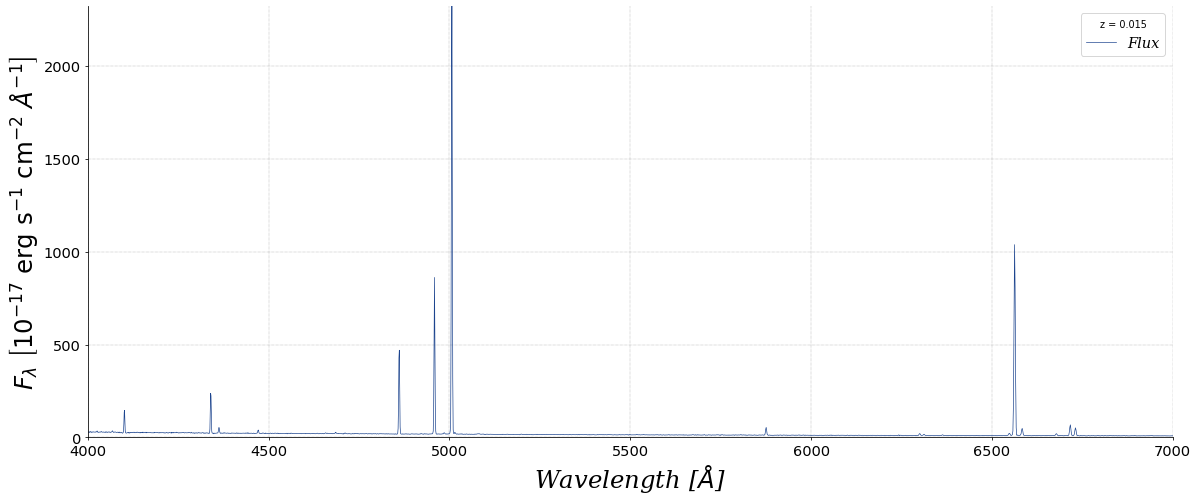

In [30]:
spec_plotter('spSpec-52992-1594-563.fit')

## CALIFA and MaNGA match

In [31]:
LMC = ['LMC','LargeMagellanicCloud','ESO056-G115','ESO052400-6948','CGS004']
IC10 = ['IC0010','UGC00192','MCG+10-01-001','2MASXJ00201733+5918136','2MASSJ00201729+5918138']
M33 = ['MESSIER033','NGC0598','TriangulumGalaxy','UGC01117','CGCG502-110','M033']
M81 = ['MESSIER081','NGC3031','UGC05318','CGCG333-007','CGCG0951.4+6918','M081']
M101 = ['MESSIER101','MESSIER102','NGC5457','UGC08981','ARP026','M101']
MRK116 = ['MRK0116','UGCA166','SBS0930+554','KUG0930+554','IZw018']
NGC0925 = ['NGC0925','UGC01913','KUG0224+333','CGCG504-085','CGCG0224.3+3321']
NGC2366 = ['NGC2366','UGC03851','DDO042','CGCG330-038','CGCG0723.6+6918']
NGC2403 = ['NGC2403','UGC03918','CGCG309-040','CGCG310-003','CGCG0732.0+6543']
NGC2541 = ['NGC2541','UGC04284','CGCG236-037','CGCG0811.0+4913','MCG+08-15-054']
NGC3198 = ['NGC3198','UGC05572','CGCG240-030','CGCG1016.9+4549','MCG+08-19-020']
NGC3319 = ['NGC3319','UGC05789','KUG1036+419','CGCG212-033','CGCG1036.2+4157']
NGC4258 = ['MESSIER106','NGC4258','UGC07353','VV448','CGCG243-067','M106']
NGC4395 = ['NGC4395','UGC07524','KUG1223+338','CGCG187-042','CGCG1223.4+3349']
NGC6822 = ['NGC6822','IC4895','DDO209','MCG-02-50-006','2MASXJ19445619-1447512']
NGC1073 = ['NGC1073','UGC02210','CGCG389-002','CGCG0241.1+0110','MCG+00-08-001']
NGC2500 = ['NGC2500','UGC04165','CGCG262-062','CGCG0758.2+5054','MCG+09-13-110']
NGC3184 = ['NGC3184','UGC05557','KUG1015+416','CGCG211-038','CGCG1015.3+4140']
M96 = ['MESSIER096','NGC3368','UGC05882','CGCG066-013','CGCG1044.1+1205','M096']
NGC3370 = ['NGC3370','UGC05887','CGCG095-019','CGCG1044.4+1732','MCG+03-28-008']
M66 = ['MESSIER066','NGC3627','UGC06346','ARP016','ARP317NED02','M066']
NGC4214 = ['NGC4214','NGC4228','UGC07278','KUG1213+366','CGCG187-032']
NGC4414 = ['NGC4414','UGC07539','ARK365','KUG1223+315','CGCG158-108']
NGC4496 = ['NGC4496','UGC07668','VV076','CGCG042-144','CGCG1229.1+0413']
NGC4535 = ['NGC4535','UGC07727','VCC1555','CGCG042-159','CGCG1231.8+0828']
NGC4536 = ['NGC4536','UGC07732','VCC1562','CGCG014-068','CGCG1232.0+0228']
NGC4725 = ['NGC4725','UGC07989','KUG1247+257B','CGCG129-027','CGCG1248.0+2546']
UGC08091 = ['UGC08091','VV558','DDO155','LSBCD646-07','VIIIZw222']
NGC5204 = ['NGC5204','UGC08490','CGCG294-039','CGCG1327.7+5840','MCG+10-19-078']
UGC09128 = ['UGC09128','DDO187','CGCG133-019','CGCG1413.6+2317','MCG+04-34-009']
NGC5584 = ['NGC5584','UGC09201','CGCG019-008','CGCG1419.8-0009','MCG+00-37-001']


GEHRs  = [LMC , IC10 , M33 , M81 , M101 , MRK116 , NGC0925 , NGC2366, NGC2403, NGC2541, NGC3198, NGC3319, NGC4258, NGC4395, NGC6822,
          NGC1073, NGC2500, NGC3184, M96, NGC3370, M66, NGC4214, NGC4414, NGC4496,  NGC4535, NGC4536, NGC4725, UGC08091, NGC5204, UGC09128
        , NGC5584]

len(GEHRs)

31

In [32]:
#CALIFA
file= HOME + "/SPS/CALIFA_servercat.txt"
local_file = os.path.join(home + "HIIGalaxies/SPS/",file)
CALIFA = pd.read_csv(local_file,header = 0,  sep='\s+')

In [33]:
for a in range(len(GEHRs)):
    GEHR_len = len(GEHRs[a])
    for b in range(GEHR_len):
        for c in range(len(CALIFA)):
            if GEHRs[a][b] in CALIFA['NAME'][c]:
                print(f"{GEHRs[a]} Found at {CALIFA['NAME'][c]} {CALIFA['FOLDER'][c]}")
        

['IC0010', 'UGC00192', 'MCG+10-01-001', '2MASXJ00201733+5918136', '2MASSJ00201729+5918138'] Found at IC0010 /data3/CALIFA.COMB


In [36]:
GEHRs_frame = pd.DataFrame(columns=['OBJ', 'RA', 'DEC'])

for a in range(len(GEHRs)):

    Name = GEHRs[a][0]
    RA = float(ned.query_object(GEHRs[a][0])['RA'])
    DEC = float(ned.query_object(GEHRs[a][0])['DEC'])
    z = float(ned.query_object(GEHRs[a][0])['Redshift'])
    last_column = ' \\ [0.3ex]'

    row = pd.DataFrame({'OBJ': [Name], 'RA': [RA], 'DEC': [DEC], 'z': [z], 'LC': [last_column]})
    GEHRs_frame = pd.concat([GEHRs_frame,row], ignore_index=True)
    del row

    #print(Name, RA, DEC)

print(HOME + '/SPS/GEHRs_updated.csv')
GEHRs_frame.to_csv(HOME + '/SPS/GEHRs_updated.csv')

/tmp/ipykernel_18708/2984301743.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  GEHRs_frame = pd.concat([GEHRs_frame,row], ignore_index=True)


/home/hollman/gdrive/DataHII//SPS/GEHRs_updated.csv


In [38]:
file="speczall-v2_4_3.fits"
local_file = os.path.join(HOME,file)

M = fits.open(local_file)

M.info()

T_manga = Table.read(M[1])
T_manga = T_manga[T_manga['FILETYPE'] == 'CUBE']
T_manga

Filename: /home/hollman/gdrive/DataHII/speczall-v2_4_3.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      10   ()      
  1  SUMMARY       1 BinTableHDU     63   9117R x 27C   [12A, 4A, 1J, 1J, 1E, 1J, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E]   


MANGA_ID,FILETYPE,PLATE,IFU,NSA_Z,NSPEC,OBJDEC,OBJRA,IFUDEC,IFURA,COMP,MEAN_Z,STD_Z,SKEW,MEDIAN_Z,IQR,Q25,Q75,R0,COMP0,MEAN_Z0,STD_Z0,SKEW0,MEDIAN_Z0,IQR0,Q250,Q750
str12,str4,int32,int32,float32,int32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
12-84620,CUBE,7443,1901,0.0187596,1024,42.06872,231.0426,42.06872,231.0426,58.496094,0.018788995,9.12368e-05,0.12479964,0.0187822,0.0001642,0.01871005,0.01887425,5.25439,32.421875,0.0187867,8.65631e-05,-0.00042155822,0.0187834,0.0001578,0.01871055,0.01886835
12-49536,CUBE,7443,1902,0.0189259,1024,42.971207,231.9911,42.971207,231.9911,56.835938,0.018906139,9.4763986e-05,0.28536385,0.01889755,0.00012475,0.0188396,0.01896435,5.9132,42.96875,0.0188972,8.50608e-05,0.29001018,0.01888805,0.000115725,0.01883415,0.018949876
12-193534,CUBE,7443,3701,0.0178955,1764,42.28702,230.57437,42.28702,230.57439,51.360546,0.017945087,0.000107035026,-0.062336504,0.01794815,0.000195825,0.01783955,0.018035375,5.87628,24.546486,0.0179524,8.93802e-05,-0.38342243,0.0179613,0.0001342,0.0178891,0.0180233
12-84670,CUBE,7443,3702,0.110451,1764,43.367775,230.59834,43.367775,230.59834,29.761906,0.11051571,4.957055e-05,0.34535018,0.110506,6.6e-05,0.110483,0.110549,5.30463,20.238094,0.110508,4.06022e-05,0.75505537,0.1105,4.8e-05,0.11048,0.110528
12-180451,CUBE,7443,3703,0.0285998,1764,43.022682,232.16734,43.022682,232.16734,1.3038548,0.013050365,0.00013817873,0.35497603,0.0130441,0.00016565,0.0129495,0.01311515,1.05089,0.6802721,0.0130765,0.000141229,0.25241765,0.0130624,0.0002443,0.01295185,0.01319615
12-84617,CUBE,7443,3704,0.0226546,1764,41.90977,231.47876,41.909775,231.47876,29.36508,0.022631867,0.00013717999,-0.41195264,0.02266565,0.000237725,0.022503875,0.0227416,4.36712,13.77551,0.022664,8.72296e-05,-0.61166954,0.0226809,0.000115,0.0226103,0.0227253
12-84726,CUBE,7443,6101,0.0309125,2916,41.294632,231.57732,41.29463,231.57732,16.838135,0.030926913,0.00014258882,0.15562789,0.030909,0.00024105,0.0308163,0.03105735,4.38287,8.470508,0.0309499,0.000129499,0.0812336,0.0309461,0.0002238,0.03083795,0.03106175
12-180432,CUBE,7443,6102,0.0280161,2704,42.354027,231.6067,42.354027,231.6067,61.83432,0.027940964,0.0002772933,-0.1616506,0.0279727,0.00051415,0.027678326,0.028192475,9.77672,44.26775,0.0279437,0.000269014,-0.14232361,0.0279729,0.0004854,0.0276954,0.0281808
12-84665,CUBE,7443,6103,0.0183422,2704,42.775543,230.23367,42.77554,230.23367,49.260357,0.018354837,0.00018756984,-0.095032096,0.0183724,0.000317575,0.018190375,0.01850795,7.5512,26.47929,0.0183685,0.000153503,-0.13002792,0.0183841,0.0002463,0.018241575,0.018487874


In [39]:
ra1 = np.array(T_manga['OBJRA'])
dec1 = np.array(T_manga['OBJDEC'])


ra2 = np.array(GEHRs_frame['RA'])
dec2 = np.array(GEHRs_frame['DEC'])




T_manga_cat = SkyCoord(ra=ra1*u.degree, 
                      dec=dec1*u.degree)


GehrS_cat = SkyCoord(ra=ra2*u.degree,
                    dec=dec2*u.degree)



idx, d2d, d3d = GehrS_cat.match_to_catalog_sky(T_manga_cat)

In [40]:
idx

array([ 742, 2302, 3958, 4529, 2136, 4532, 3952, 2496, 2496, 2623, 1646,
        890, 1027, 2041, 2392,  263, 2533, 1666, 1545, 1545, 1585, 2037,
       2041, 1385, 4313, 1082, 4313, 1082, 1066, 1453, 1200])

In [41]:
for i in range(len(idx)):
    if (d2d[i] < (0.2 * u.degree)):
        print(f"IDX_GEHRs: {i}  IDX_MaNGA: {idx[i]}, {GEHRs_frame['OBJ'][i]}: RA: {GEHRs_frame['RA'][i]}, DEC: {GEHRs_frame['DEC'][i]} || MaNGA Closest: RA: {T_manga['OBJRA'][idx[i]]}, DEC: {T_manga['OBJDEC'][idx[i]]} Sep: {d2d[i]}")

IDX_GEHRs: 21  IDX_MaNGA: 2037, NGC4214: RA: 183.91321, DEC: 36.32689 || MaNGA Closest: RA: 183.7891082763672, DEC: 36.33662033081055 Sep: 0.10044872637049271 deg


In [42]:
T_manga[2037]

MANGA_ID,FILETYPE,PLATE,IFU,NSA_Z,NSPEC,OBJDEC,OBJRA,IFUDEC,IFURA,COMP,MEAN_Z,STD_Z,SKEW,MEDIAN_Z,IQR,Q25,Q75,R0,COMP0,MEAN_Z0,STD_Z0,SKEW0,MEDIAN_Z0,IQR0,Q250,Q750
str12,str4,int32,int32,float32,int32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
1-419607,CUBE,8554,9102,0.148181,4356,36.33662,183.78911,36.33662,183.78911,9.802571,0.14818831,0.00010278702,-0.1896622,0.148196,0.0001065,0.1481355,0.148242,5.24072,7.621671,0.148195,7.51148e-05,0.06260692,0.148196,9e-05,0.148145,0.148235


In [43]:
ra1 = np.array(T_manga['OBJRA'])
dec1 = np.array(T_manga['OBJDEC'])


ra2 = np.array(NED['RA'])
dec2 = np.array(NED['Dec'])




T_manga_cat = SkyCoord(ra=ra1*u.degree, 
                      dec=dec1*u.degree)


NeD_cat = SkyCoord(ra=ra2*u.degree,
                    dec=dec2*u.degree)



idx, d2d, d3d = NeD_cat.match_to_catalog_sky(T_manga_cat)

In [45]:
for i in range(len(idx)):
    if (d2d[i] < (6 * u.arcmin)):
        print(f"IDX_NED: {i}  IDX_MaNGA: {idx[i]}, {NED['ObjectName'][i]}: RA: {NED['RA'][i]}, DEC: {NED['Dec'][i]} || MaNGA Closest: RA: {T_manga['OBJRA'][idx[i]]}, DEC: {T_manga['OBJDEC'][idx[i]]} Sep: {d2d[i]}")

IDX_NED: 14  IDX_MaNGA: 1544, WAS 17: RA: 167.1603851, DEC: 22.6360635 || MaNGA Closest: RA: 167.11375427246094, DEC: 22.619579315185547 Sep: 0.04609013871158899 deg
IDX_NED: 49  IDX_MaNGA: 4301, SHOC 247: RA: 139.2178522, DEC: 0.5203883 || MaNGA Closest: RA: 139.2084503173828, DEC: 0.5727083683013916 Sep: 0.05315802353997852 deg
IDX_NED: 72  IDX_MaNGA: 2348, WISEA J212043.94+010006.9: RA: 320.1831085, DEC: 1.0019185 || MaNGA Closest: RA: 320.1594543457031, DEC: 1.0472772121429443 Sep: 0.05115423724271792 deg


In [46]:
NED[72:73]

,No.,ObjectName,RA,Dec,Redshift(z)
72,73,WISEA J212043.94+010006.9,320.183109,1.001918,0.113752


In [47]:
T_manga[1544]

MANGA_ID,FILETYPE,PLATE,IFU,NSA_Z,NSPEC,OBJDEC,OBJRA,IFUDEC,IFURA,COMP,MEAN_Z,STD_Z,SKEW,MEDIAN_Z,IQR,Q25,Q75,R0,COMP0,MEAN_Z0,STD_Z0,SKEW0,MEDIAN_Z0,IQR0,Q250,Q750
str12,str4,int32,int32,float32,int32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
1-487383,CUBE,8448,6104,0.021597,2916,22.61958,167.11375,22.61958,167.11375,53.46365,0.021729726,0.00017828781,-0.11666808,0.0217425,0.0002792,0.0215879,0.0218671,3.75832,6.138546,0.0217572,7.73549e-05,-0.62639326,0.0217757,0.00011185,0.02170685,0.0218187


In [48]:
T_manga[4301]

MANGA_ID,FILETYPE,PLATE,IFU,NSA_Z,NSPEC,OBJDEC,OBJRA,IFUDEC,IFURA,COMP,MEAN_Z,STD_Z,SKEW,MEDIAN_Z,IQR,Q25,Q75,R0,COMP0,MEAN_Z0,STD_Z0,SKEW0,MEDIAN_Z0,IQR0,Q250,Q750
str12,str4,int32,int32,float32,int32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
1-605753,CUBE,9512,9101,0.0283994,4096,0.57270837,139.20845,0.57270837,139.20847,34.057617,0.02834474,0.00038659468,0.14952274,0.0282893,0.0007012,0.02800865,0.02870985,3.47921,3.6621094,0.0284009,0.000175986,-0.28496498,0.0284161,0.000246975,0.028280126,0.0285271


In [49]:
T_manga[2348]

MANGA_ID,FILETYPE,PLATE,IFU,NSA_Z,NSPEC,OBJDEC,OBJRA,IFUDEC,IFURA,COMP,MEAN_Z,STD_Z,SKEW,MEDIAN_Z,IQR,Q25,Q75,R0,COMP0,MEAN_Z0,STD_Z0,SKEW0,MEDIAN_Z0,IQR0,Q250,Q750
str12,str4,int32,int32,float32,int32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
1-596218,CUBE,8615,12702,0.0207444,5476,1.0472772,320.15945,1.0472772,320.15945,45.909424,0.020706369,0.00019089041,0.06173585,0.0207029,0.00029025,0.0205563,0.02084655,8.69039,17.238861,0.0207106,0.000136899,-0.029037159,0.02072005,0.0002374,0.0205923,0.0208297
